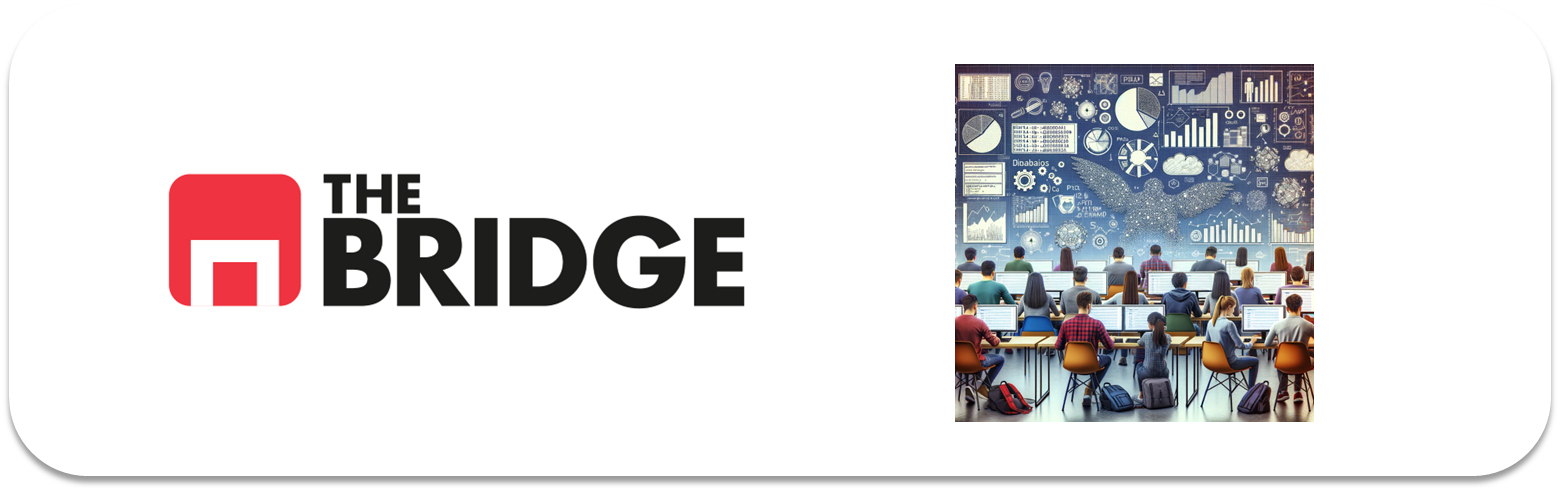

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.

In [3]:
df = pd.read_csv('./data/hard_to_find/obligatoria_hard.csv', sep = '|')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.

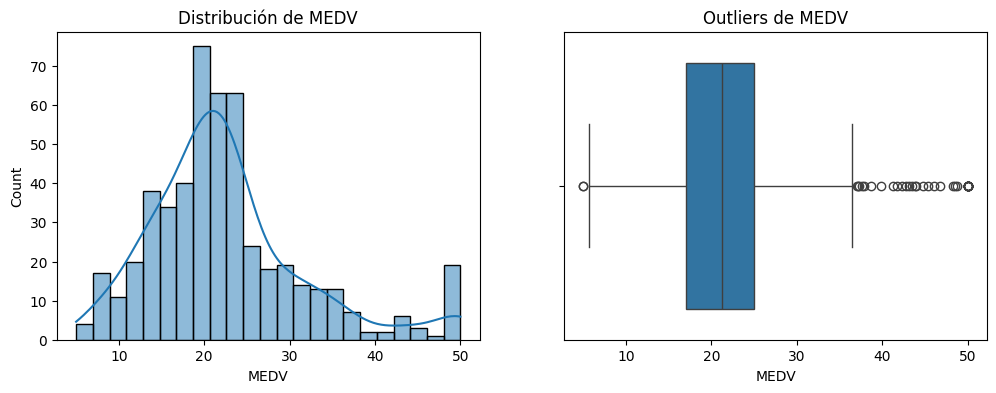

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['MEDV'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de MEDV')
sns.boxplot(x=df['MEDV'], ax=axes[1])
axes[1].set_title('Outliers de MEDV')
plt.show()

*valor 50 como cap artificial del data set original, censura de valores: el modelo va a tener problemas para predecir bien las viviendas más caras (esos puntos meten ruido/sesgo)*

3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

4. Construye las parejas X,y de train y test

In [6]:
X_train = train_df.drop(columns='MEDV')
y_train = train_df['MEDV']

X_test = test_df.drop(columns='MEDV')
y_test = test_df['MEDV']

5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

In [7]:
df_eda = X_train.copy()
df_eda["target"] = y_train
df_eda

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,target
477,15.02340,0.0,18.10,0.0,0.6140,5.304,97.3,2.1007,24.0,666.0,20.2,24.91,12.0
15,0.62739,0.0,8.14,0.0,0.5380,5.834,56.5,4.4986,4.0,307.0,21.0,8.47,19.9
332,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,1.0,304.0,16.9,7.83,19.4
423,7.05042,0.0,18.10,0.0,0.6140,6.103,85.1,2.0218,24.0,666.0,20.2,23.29,13.4
19,0.72580,0.0,8.14,0.0,0.5380,5.727,69.5,3.7965,4.0,307.0,21.0,11.28,18.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0.0,0.5200,5.836,91.9,2.2110,5.0,384.0,20.9,18.66,19.5
270,0.29916,20.0,6.96,0.0,0.4640,5.856,42.1,4.4290,3.0,223.0,18.6,13.00,21.1
348,0.01501,80.0,2.01,0.0,0.4350,6.635,29.7,8.3440,4.0,280.0,17.0,5.99,24.5
435,11.16040,0.0,18.10,0.0,0.7400,6.629,94.6,2.1247,24.0,666.0,20.2,23.27,13.4


In [8]:
df_eda.corr(numeric_only= True)["target"].sort_values(ascending = False)

target     1.000000
RM         0.710680
ZN         0.309504
DIS        0.235114
CHAS       0.190642
AGE       -0.340216
CRIM      -0.380091
RAD       -0.387467
NOX       -0.415768
TAX       -0.459795
INDUS     -0.470546
PTRATIO   -0.491210
LSTAT     -0.736422
Name: target, dtype: float64

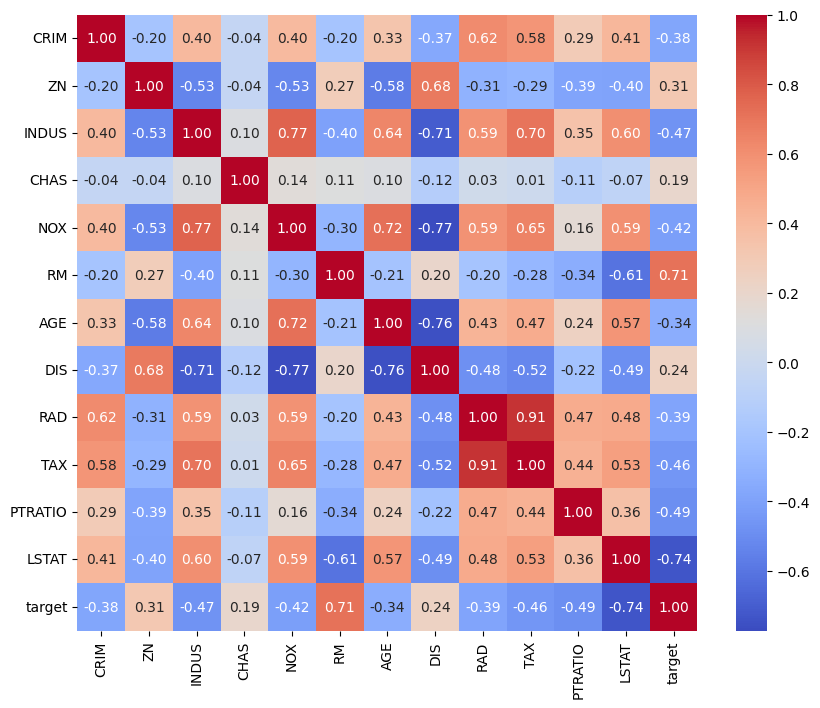

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

*Nos quedamos con RM y LSTAT como features fuertes, descarto RAD (nos quedamos con TAX, para evitar multicolinealidad), y dejamos el resto salvo que decidamos filtrar alguna más floja (ZN, CHAS, DIS rondan correlaciones bajas con target, <0.25 en valor absoluto)*

In [10]:
features = X_train.columns.drop('RAD')
X_train_sel = X_train[features]
X_test_sel = X_test[features]

6. Trata las variables para que funcionen lo mejor posible en el modelo.

In [11]:
X_train_sel.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT
477,15.02340,0.0,18.10,0.0,0.6140,5.304,97.3,2.1007,666.0,20.2,24.91
15,0.62739,0.0,8.14,0.0,0.5380,5.834,56.5,4.4986,307.0,21.0,8.47
332,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,304.0,16.9,7.83
423,7.05042,0.0,18.10,0.0,0.6140,6.103,85.1,2.0218,666.0,20.2,23.29
19,0.72580,0.0,8.14,0.0,0.5380,5.727,69.5,3.7965,307.0,21.0,11.28


In [12]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = features.drop('CHAS')

scaler = StandardScaler()
X_train_scaled = X_train_sel.copy()
X_test_scaled = X_test_sel.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_sel[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test_sel[cols_to_scale])

7. Construye un modelo de regresión lineal.

In [13]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = lin_reg.predict(X_test_scaled)
y_pred

array([28.83703824, 36.05062396, 17.88232445, 25.14506779, 17.01636603,
       23.9580539 , 17.55710829, 15.10145605, 21.07867758, 21.00355163,
       24.27027505, 18.09676719, -4.01591084, 22.30513673, 19.06121432,
       24.65998606, 19.1091061 ,  3.99393979, 39.84372196, 15.75401583,
       26.79571508, 29.44195291, 11.96636936, 24.88649618, 16.94637321,
       14.37163455, 23.24358534, 17.57514777, 22.55452431, 19.55889463,
       22.09675436, 25.10954983, 24.38111059, 16.05681412, 15.50197803,
       18.36693998, 31.41721571, 19.52567176, 24.09839447, 24.89760561,
       14.15556874, 30.95127145, 41.54650673, 17.7848984 , 27.8582197 ,
       15.10104958, 14.78125501, 26.11264613, 18.31571873, 30.77917979,
       20.68506415, 33.2426431 , 16.31822834, 27.20102902, 38.82995719,
       20.81637691, 16.98702302, 32.08942475, 25.07568296, 12.38433428,
       21.73157313, 29.44267918, 30.95756283, 17.58913985, 21.77280102,
       16.64033896, 18.74229323, 25.95178946, 30.36880071, 14.41

8. Analiza si lo crees conveniente los pesos y la importancia de las features.

In [15]:
coefs = pd.Series(lin_reg.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)
print(coefs)

LSTAT     -3.729968
CHAS       3.352529
RM         3.199445
DIS       -3.079570
NOX       -1.952571
PTRATIO   -1.789354
CRIM      -0.862415
ZN         0.540795
AGE       -0.189403
INDUS     -0.170934
TAX       -0.094288
dtype: float64


*pesos absolutos* != *correlación simple*

*correlación simple = efecto aislado. Coeficiente de regresión múltiple = efecto neto*

Comparación con los coefs anteriores:

*TAX estaba correlacionada 0.91 con RAD (que quitaste) y 0.65 con NOX, 0.77 con INDUS. Como esas variables siguen en el modelo, "cubren" buena parte de la información que aportaba TAX por su cuenta. El modelo le reparte el "crédito" a las otras, y a TAX le queda poco peso propio.*

*TAX queda "redundante" porque otras variables correlacionadas con ella (NOX, INDUS, RAD que quitamos...) ya capturan esa misma información, así que el modelo no necesita usar TAX para explicar el efecto.*

*DIS estaba muy correlacionada con NOX (-0.77) y AGE (-0.76). Aun así sube bastante de peso, lo que sugiere que aporta información propia que las demás no capturan del todo, una vez controladas.*

*CHAS apenas correlaciona con nada más (eso viste en el heatmap), así que su coeficiente refleja casi puramente su propio efecto — y resulta que viviendas junto al río suben bastante el precio cuando controlas el resto.*

8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

argumentos = (y_test.values, y_pred)

print('MSE:', mean_squared_error(*argumentos))
print('RMSE:', np.sqrt(mean_squared_error(*argumentos)))
print('MAE:', mean_absolute_error(*argumentos))
print('MAPE:', mean_absolute_percentage_error(*argumentos))
print('R2:', lin_reg.score(X_test_scaled, y_test))

MSE: 24.83912139820296
RMSE: 4.98388617428237
MAE: 3.2525029724319587
MAPE: 0.17150567012802231
R2: 0.6612867858746704


*RMSE: En promedio, el modelo se equivoca unos 5.000 dólares al predecir el precio de una vivienda*

*MAE vs RMSE: cuando RMSE > MAE de forma notable (4.98 vs 3.25), significa que el modelo tiene algunos errores puntuales grandes que están "inflando" el RMSE, mientras que la mayoría de predicciones tienen un error más modesto (cercano al MAE). Si MAE y RMSE fueran prácticamente iguales, los errores estarían distribuidos de forma más uniforme, sin grandes "patinazos".*

*esto se debe al valor 50 que vimos de la variable target MEDV*

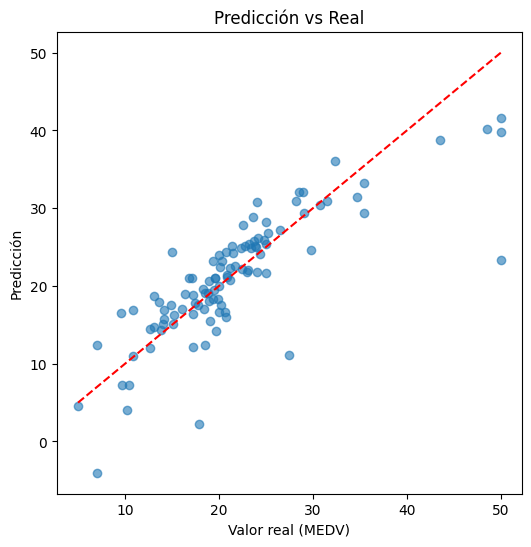

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valor real (MEDV)')
plt.ylabel('Predicción')
plt.title('Predicción vs Real')
plt.show()

*El modelo subestima sistemáticamente esos valores topados en 50 (predice entre 23 y 42 cuando el real es 50*

9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.

In [18]:
from sklearn.linear_model import Ridge

alphas = [0.1, 1, 10]
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    print(f'alpha={alpha} -> RMSE: {rmse:.3f}, R2: {ridge.score(X_test_scaled, y_test):.3f}')

alpha=0.1 -> RMSE: 4.984, R2: 0.661
alpha=1 -> RMSE: 4.982, R2: 0.662
alpha=10 -> RMSE: 4.974, R2: 0.663


In [ ]:
y_pred_train = lin_reg.predict(X_train_scaled)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print('RMSE train:', rmse_train)
print('RMSE test:', 4.984) 

RMSE train: 4.8125467426281645
RMSE test: 4.984


*RMSE train ≈ RMSE test → el modelo generaliza bien, no hay overfitting significativo. Por eso Ridge (que corrige overfitting) apenas cambió nada — no había mucho que corregir.*

10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?

*La mejora de Ridge es marginal (4.984 vs 4.974), así que no compensa añadir un hiperparámetro y complejidad extra para un beneficio casi inexistente*